# TASK 3 – Car Price Prediction

## Objective
Build a machine learning regression model to predict the selling price of a used car from features such as present price, kilometres driven, fuel type, seller type, transmission, owner history, and car age.

**Dataset:** Kaggle CarDekho Used Car Dataset (`car data.csv`)

## Before running
Download **`car data.csv`** from the Kaggle Car Price Prediction / CarDekho dataset and put it in the **same folder as this notebook**.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the Dataset

In [2]:
df = pd.read_csv("car data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Dataset Inspection

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all"))

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

Missing values:


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


Duplicate rows: 2

Descriptive statistics:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


## 3. Data Cleaning

In [4]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates().reset_index(drop=True)

# Create car age from manufacturing year
df["Car_Age"] = pd.Timestamp.now().year - df["Year"]

print("Shape after cleaning:", df.shape)
display(df.head())

Shape after cleaning: (299, 10)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


### Observation
- `Selling_Price` is the target variable.
- Numerical variables include `Year`, `Present_Price`, `Kms_Driven`, `Owner`, and `Car_Age`.
- `Fuel_Type`, `Seller_Type`, and `Transmission` are categorical variables.
- Duplicate records are removed before modelling.

## 4. Exploratory Data Analysis

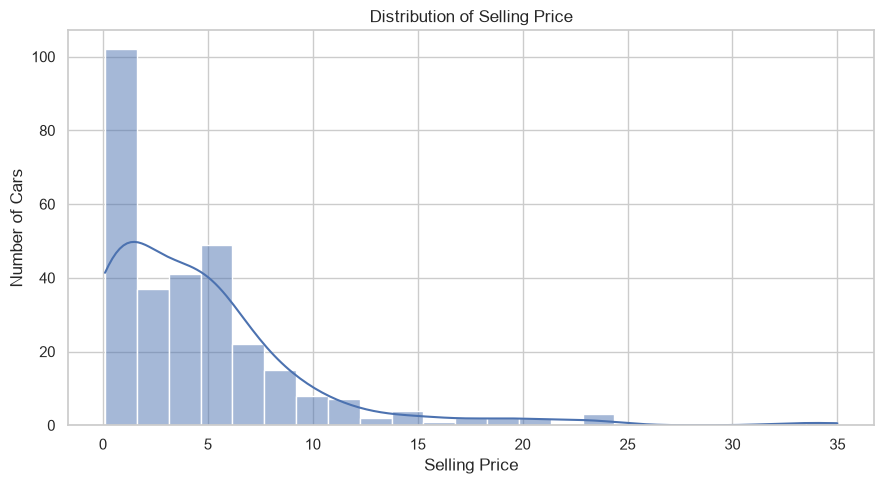

In [5]:
plt.figure(figsize=(9,5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

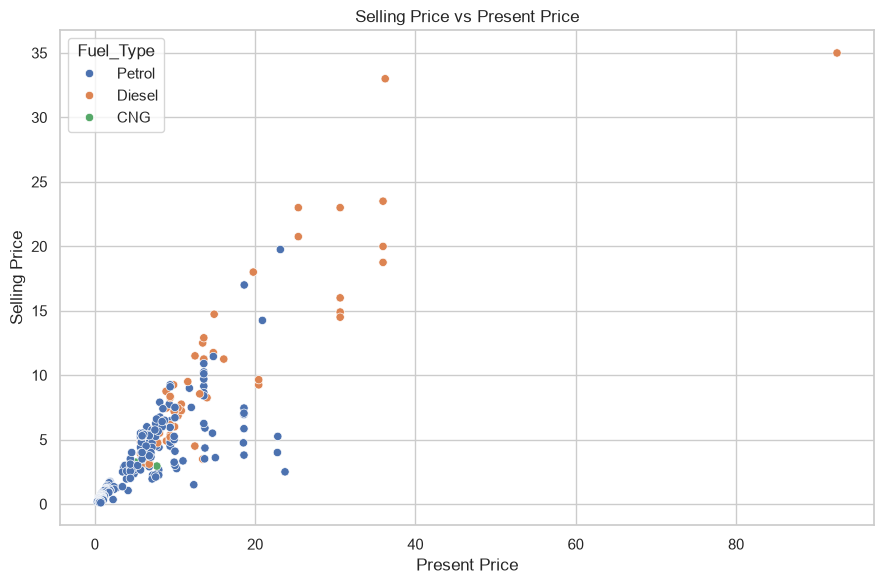

In [6]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type")
plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

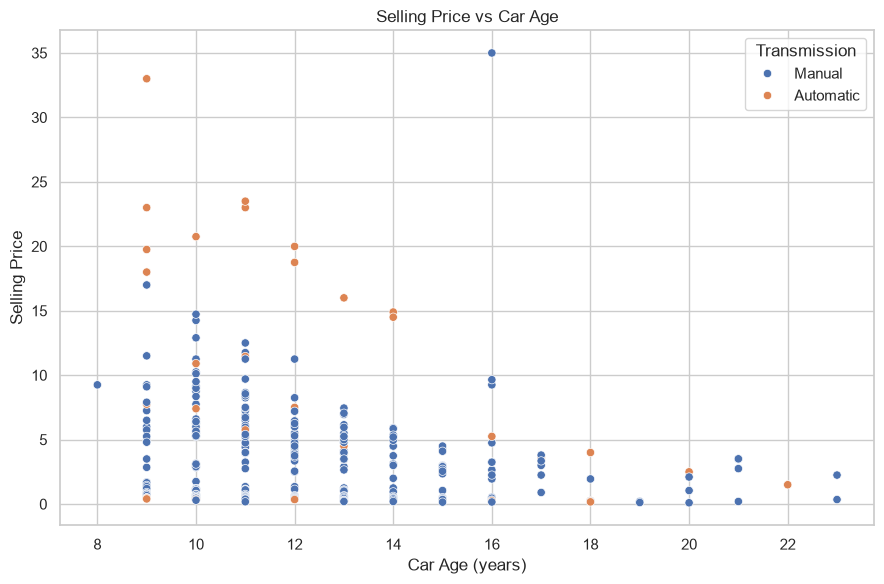

In [7]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Transmission")
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

### EDA Observation
`Present_Price` generally has a strong positive relationship with `Selling_Price`. Older cars generally sell for less, while fuel type and transmission can also influence resale value.

## 5. Correlation Heatmap

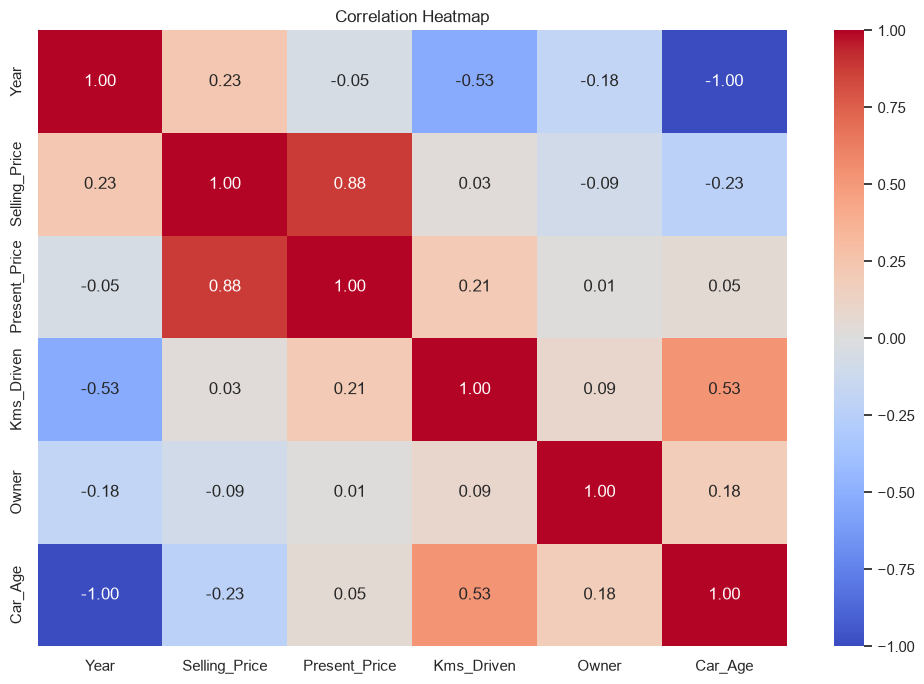

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Prepare Features and Target

In [9]:
features = [
    "Present_Price", "Kms_Driven", "Fuel_Type",
    "Seller_Type", "Transmission", "Owner", "Car_Age"
]

X = df[features]
y = df["Selling_Price"]

categorical_features = ["Fuel_Type", "Seller_Type", "Transmission"]
numerical_features = ["Present_Price", "Kms_Driven", "Owner", "Car_Age"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 239
Testing samples: 60


## 7. Preprocessing and Model Training

In [10]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []
trained_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2 Score": r2_score(y_test, predictions)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
display(results_df)

,Model,MAE,RMSE,R2 Score
1,Ridge Regression,1.487190,2.522446,0.753127
0,Linear Regression,1.472892,2.524035,0.752815
3,Gradient Boosting,1.186626,2.603978,0.736909
2,Random Forest,1.464337,3.487276,0.528151


### Evaluation Metrics
- **MAE:** average absolute prediction error. Lower is better.
- **RMSE:** penalizes larger errors more strongly. Lower is better.
- **R² Score:** proportion of price variation explained by the model. Higher is better.

## 8. Select the Best Model

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print("Best Model:", best_model_name)
print(f"MAE: {mean_absolute_error(y_test, best_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_predictions)):.2f}")
print(f"R2 Score: {r2_score(y_test, best_predictions):.4f}")

Best Model: Ridge Regression
MAE: 1.49
RMSE: 2.52
R2 Score: 0.7531


## 9. Actual vs Predicted Prices

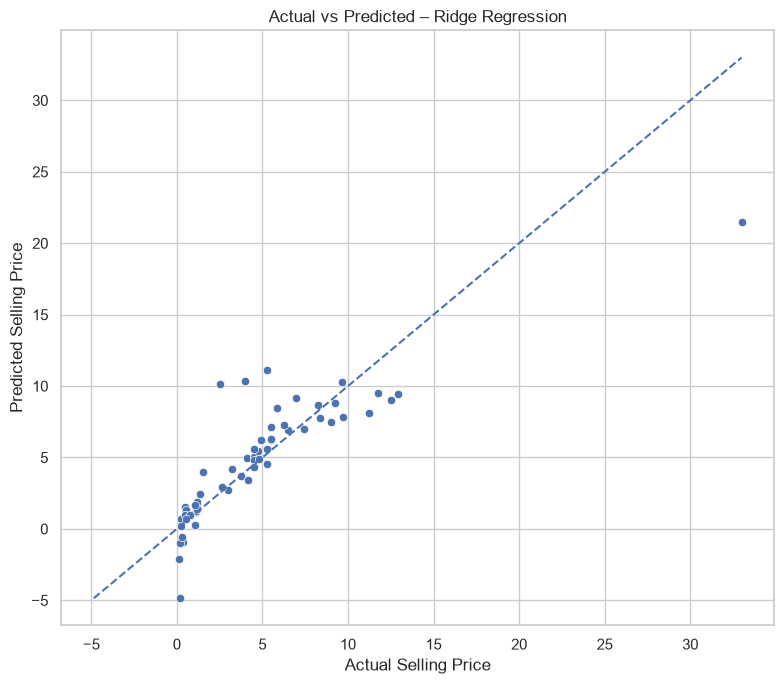

In [12]:
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=best_predictions)

low = min(y_test.min(), best_predictions.min())
high = max(y_test.max(), best_predictions.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Actual vs Predicted – {best_model_name}")
plt.tight_layout()
plt.show()

## 10. Residual Analysis

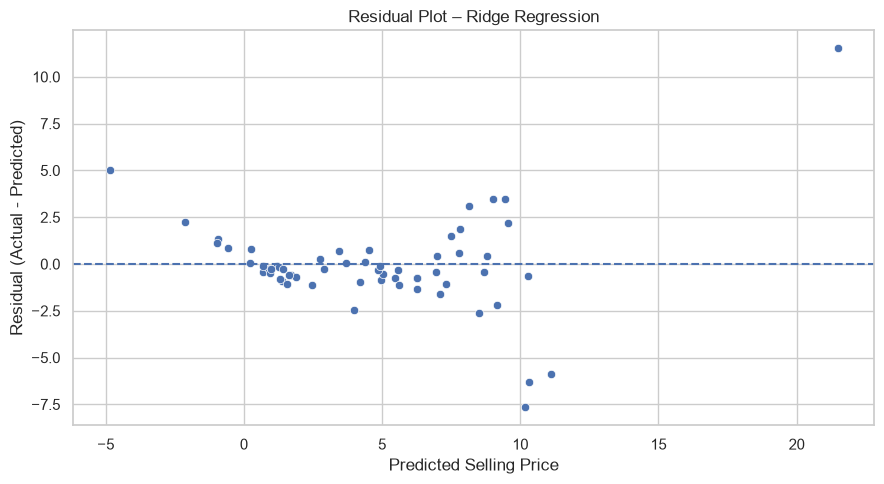

In [13]:
residuals = y_test - best_predictions

plt.figure(figsize=(9,5))
sns.scatterplot(x=best_predictions, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot – {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Feature Importance

In [14]:
rf = trained_models["Random Forest"]

feature_names = rf.named_steps["preprocessor"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

,Feature,Importance
0,num__Present_Price,0.903240
3,num__Car_Age,0.073042
1,num__Kms_Driven,0.013483
7,cat__Transmission_Manual,0.005285
6,cat__Seller_Type_Individual,0.002979
4,cat__Fuel_Type_Diesel,0.001060
5,cat__Fuel_Type_Petrol,0.000901
2,num__Owner,0.000009


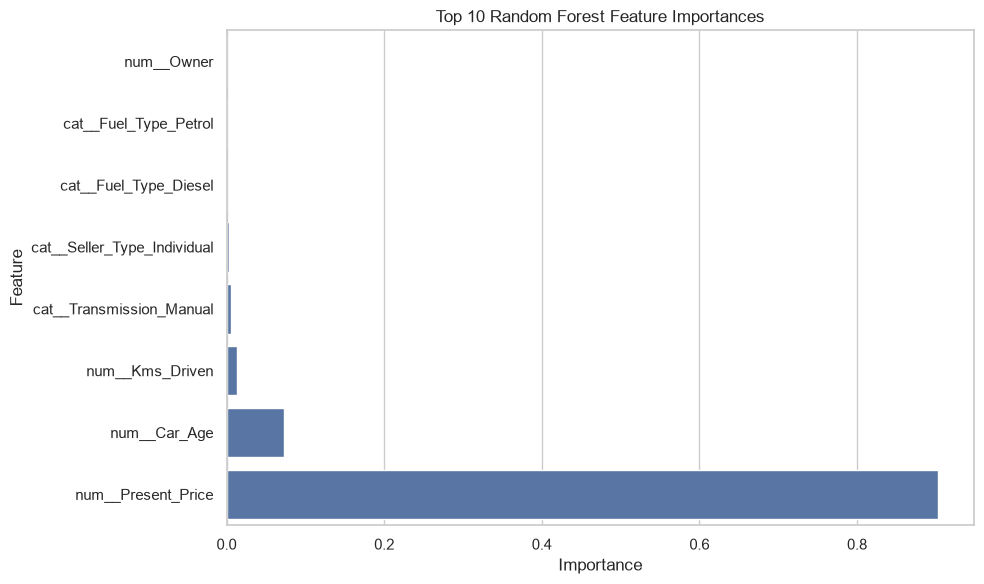

In [15]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 12. Example Prediction

In [16]:
example_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Kms_Driven": [30000],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0],
    "Car_Age": [4]
})

predicted_price = best_model.predict(example_car)[0]
print(f"Predicted selling price: {predicted_price:.2f} lakh")

Predicted selling price: 7.84 lakh


## 13. Final Conclusion

The Car Price Prediction task was completed using a machine-learning regression workflow. The dataset was cleaned, explored and visualized, categorical features were one-hot encoded, and the data was split into 80% training and 20% testing sets.

Four regression models were compared: **Linear Regression, Ridge Regression, Random Forest and Gradient Boosting**. They were evaluated using **MAE, RMSE and R² Score**, and the model with the highest R² score was selected as the best model.

The analysis generally shows that **present price, car age and usage-related variables** are important factors in estimating the resale price of a used car.